# Entrenamiento de modelos de clasificación binaria: Random Forest vs XGBoost
### Predicción de `VENTAJA` a partir del estado del tablero y la carta jugada

Este notebook sigue 5 secciones:

1. Análisis exploratorio de datos (EDA)
2. Preprocesamiento de los datos
3. Entrenamiento de los modelos y selección del ganador **basada en validación cruzada**
4. Tuning del modelo ganador (usando el set de **test únicamente** para evaluar el
   modelo final ya tuneado)
5. Interpretabilidad con SHAP

**Importante sobre el uso del set de test:** para evitar sesgar la elección de modelo con
el set de test, la selección entre Random Forest y XGBoost (sección 3) se hace
completamente con **validación cruzada sobre el set de entrenamiento** (métricas,
matrices de confusión y curva ROC calculadas con predicciones *out-of-fold*). El set de
test se reserva exclusivamente para la evaluación final del modelo ganador ya tuneado
(sección 4).

In [1]:
# Librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    train_test_split, cross_validate, cross_val_predict,
    StratifiedKFold, RandomizedSearchCV,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve,
)
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [2]:
# Carga de datos
# Ajustar la ruta si el archivo se encuentra en otra ubicación
DATA_PATH = "dataset2.csv"

df = pd.read_csv(DATA_PATH, sep=";")
print("Shape:", df.shape)
df.head()

Shape: (2907, 21)


,C1A,C1B,C1C,C2A,C2B,C2C,C3A,C3B,C3C,T1A,...,T1C,T2A,T2B,T2C,T3A,T3B,T3C,RONDA,TURNO,VENTAJA
0,0,0,1,0,0,2,0,4,1,0,...,0,0,0,0,0,0,0,1,1,1
1,0,0,4,1,0,0,2,1,0,0,...,-1,0,0,-2,0,-4,-1,1,2,0
2,1,0,1,0,3,0,0,3,0,0,...,-1,0,0,-2,0,-4,-1,1,2,0
3,2,0,0,1,0,3,2,0,0,0,...,-1,0,0,-2,0,-4,-1,1,2,0
4,1,4,0,2,0,0,1,0,0,0,...,-1,0,0,-2,0,-4,-1,1,2,0


## 1. Análisis exploratorio de datos (EDA)

### 1.1 Estructura general, tipos de datos, faltantes y duplicados

In [3]:
print("Tipos de datos:")
print(df.dtypes)
print()
print("Valores faltantes totales:", df.isna().sum().sum())
print("Filas duplicadas (todas las columnas):", df.duplicated().sum())
df.describe().T

Tipos de datos:
C1A        int64
C1B        int64
C1C        int64
C2A        int64
C2B        int64
C2C        int64
C3A        int64
C3B        int64
C3C        int64
T1A        int64
T1B        int64
T1C        int64
T2A        int64
T2B        int64
T2C        int64
T3A        int64
T3B        int64
T3C        int64
RONDA      int64
TURNO      int64
VENTAJA    int64
dtype: object

Valores faltantes totales: 0
Filas duplicadas (todas las columnas): 0


,count,mean,std,min,25%,50%,75%,max
C1A,2907.0,0.640179,0.942903,0.0,0.0,0.0,1.0,4.0
C1B,2907.0,0.974544,1.177344,0.0,0.0,0.0,2.0,4.0
C1C,2907.0,0.568627,0.889848,0.0,0.0,0.0,1.0,4.0
C2A,2907.0,0.949432,1.174922,0.0,0.0,0.0,2.0,4.0
C2B,2907.0,1.750946,1.507915,0.0,0.0,3.0,3.0,4.0
C2C,2907.0,0.964912,1.171234,0.0,0.0,0.0,2.0,4.0
C3A,2907.0,0.582731,0.902481,0.0,0.0,0.0,1.0,4.0
C3B,2907.0,0.951840,1.154192,0.0,0.0,0.0,2.0,4.0
C3C,2907.0,0.616787,0.921768,0.0,0.0,0.0,1.0,4.0
T1A,2907.0,-0.392501,1.359775,-4.0,-1.0,0.0,0.0,3.0


### 1.2 Validación de las reglas del juego

Se valida que las variables de carta (`C1A...C3C`) cumplan las reglas descritas:
- La suma de las 9 posiciones de carta debe ser siempre 8.
- Exactamente 4 posiciones deben tener valores distintos de 0 (con valores del 1 al 4).

In [4]:
card_cols = ["C1A","C1B","C1C","C2A","C2B","C2C","C3A","C3B","C3C"]

card_sum = df[card_cols].sum(axis=1)
n_nonzero = (df[card_cols] != 0).sum(axis=1)

print("Filas con suma de carta != 8:", (card_sum != 8).sum())
print("Filas con cantidad de posiciones no-cero != 4:", (n_nonzero != 4).sum())

Filas con suma de carta != 8: 0
Filas con cantidad de posiciones no-cero != 4: 0


### 1.3 Distribución de `RONDA` y `TURNO`

`RONDA` está desbalanceada (las rondas avanzadas 4 y 5 tienen muchas menos muestras que
las iniciales). Como el split y la validación cruzada se estratifican por `VENTAJA` (ver
sección 2), aquí solo se documenta la distribución de `RONDA`/`TURNO`; más adelante se
verifica que la proporción de `RONDA` no quede demasiado distorsionada entre train y
test.

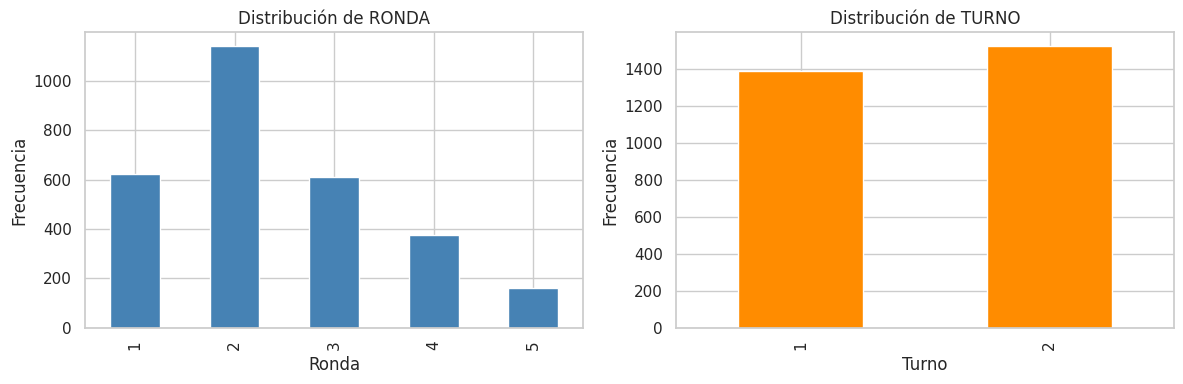

TURNO    1    2
RONDA          
1       13  611
2      691  450
3      352  257
4      210  164
5      120   39


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["RONDA"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Distribución de RONDA")
axes[0].set_xlabel("Ronda")
axes[0].set_ylabel("Frecuencia")

df["TURNO"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Distribución de TURNO")
axes[1].set_xlabel("Turno")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

print(pd.crosstab(df["RONDA"], df["TURNO"]))

### 1.4 Distribución de la variable objetivo `VENTAJA`

`VENTAJA` es una variable **binaria** (0/1). Se revisa el balance de clases, dato clave
para elegir el baseline correcto y para interpretar métricas como accuracy (poco
informativa si hay desbalance fuerte) frente a precision/recall/F1/ROC-AUC.

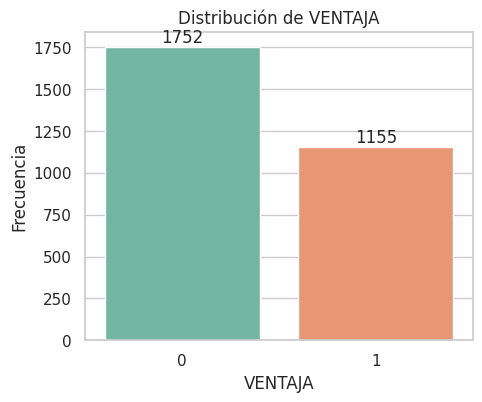

VENTAJA
0    1752
1    1155
Name: count, dtype: int64

Proporción de clases:
VENTAJA
0    0.602683
1    0.397317
Name: proportion, dtype: float64


In [6]:
plt.figure(figsize=(5, 4))
ax = sns.countplot(x=df["VENTAJA"], hue=df["VENTAJA"], palette="Set2", legend=False)
plt.title("Distribución de VENTAJA")
plt.xlabel("VENTAJA")
plt.ylabel("Frecuencia")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
plt.show()

print(df["VENTAJA"].value_counts())
print()
print("Proporción de clases:")
print(df["VENTAJA"].value_counts(normalize=True))

### 1.5 Distribución de las posiciones de carta

Se revisa en particular `C2B`, que muestra una distribución distinta al resto de
posiciones (más frecuencia de valor 3, menos ceros).

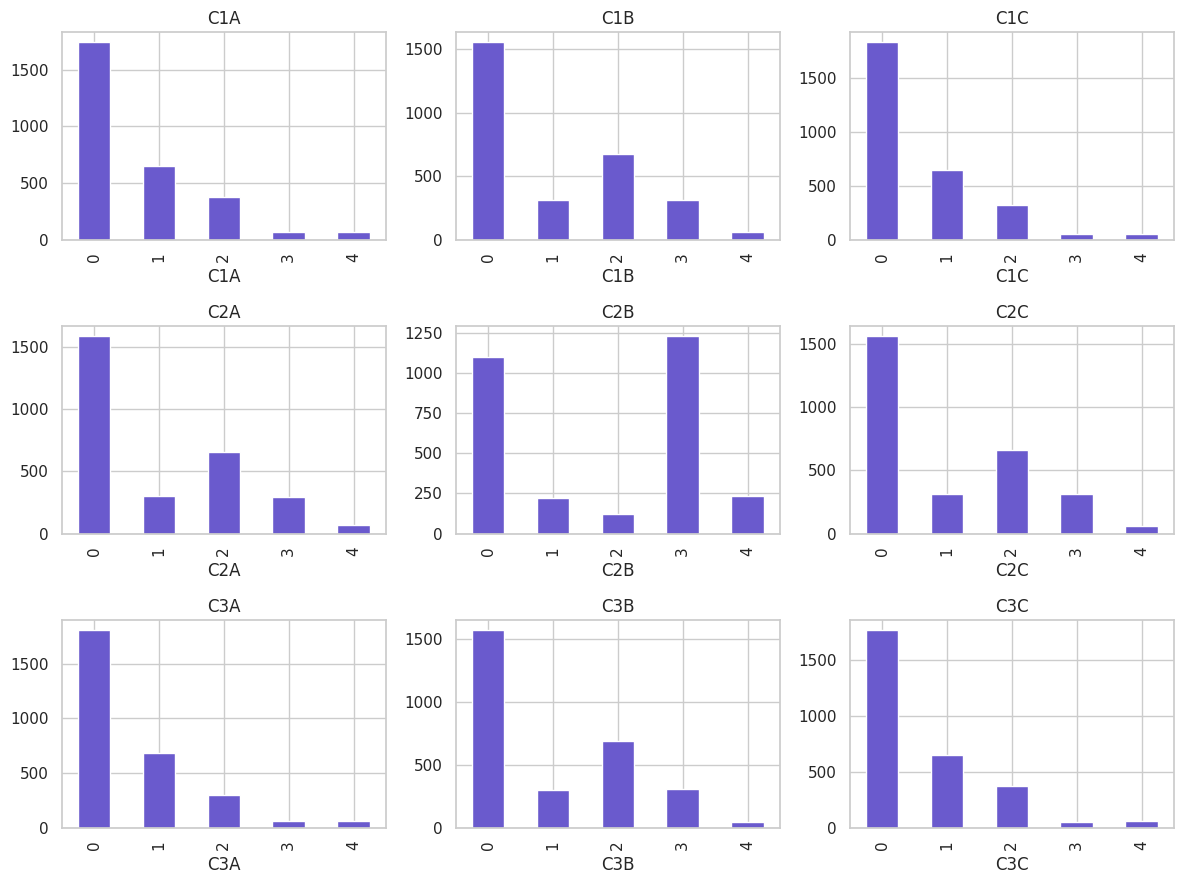

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(12, 9))
for ax, col in zip(axes.ravel(), card_cols):
    df[col].value_counts().sort_index().plot(kind="bar", ax=ax, color="slateblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()

### 1.6 Multicolinealidad entre variables del tablero (`T*`)

Las variables de tablero comparten restricciones de suma entre celdas, por lo que es
esperable que existan correlaciones fuertes entre algunas de ellas. No se eliminan
variables porque Random Forest y XGBoost son robustos a la colinealidad, pero es
importante tenerlo presente al interpretar la importancia de variables.

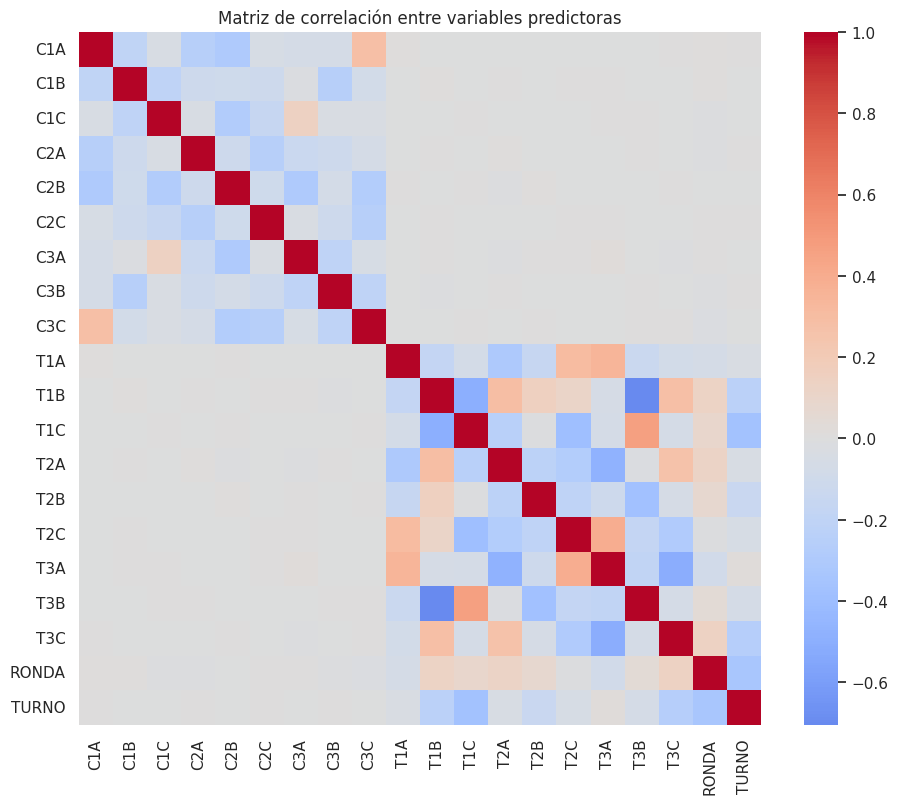

,var_1,var_2,correlacion
1,T1B,T3B,-0.705
2,T3A,T3C,-0.510
0,T1B,T1C,-0.501


In [8]:
feature_cols = [c for c in df.columns if c != "VENTAJA"]

plt.figure(figsize=(11, 9))
corr = df[feature_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Matriz de correlación entre variables predictoras")
plt.show()

# Pares con correlación fuerte (|r| > 0.5)
pairs = []
for i in range(len(feature_cols)):
    for j in range(i + 1, len(feature_cols)):
        a, b = feature_cols[i], feature_cols[j]
        v = corr.loc[a, b]
        if abs(v) > 0.5:
            pairs.append((a, b, round(v, 3)))

pd.DataFrame(pairs, columns=["var_1", "var_2", "correlacion"]).sort_values(
    "correlacion", key=abs, ascending=False
)

Definimos los grupos de variables (carta, tablero, ronda, turno) y sus colores, para
usarlos consistentemente en los gráficos de correlación e importancia de variables del
resto del notebook.

In [9]:
group_map = {}
for c in card_cols:  # C1A...C3C
    group_map[c] = "Carta"
for c in [c for c in feature_cols if c.startswith("T")]:
    group_map[c] = "Tablero"
group_map["RONDA"] = "Ronda"
group_map["TURNO"] = "Turno"

group_colors = {"Carta": "teal", "Tablero": "steelblue", "Ronda": "darkorange", "Turno": "seagreen"}

### 1.7 Relación de cada variable con `VENTAJA`, agrupada por carta/tablero/ronda/turno

Al ser `VENTAJA` binaria, la correlación de Pearson de cada variable contra `VENTAJA`
equivale a una correlación punto-biserial, y sirve como primera aproximación (lineal) de
qué variables separan mejor las dos clases. Se colorea cada barra según el grupo al que
pertenece la variable (carta, tablero, ronda o turno) para identificar de un vistazo qué
tipo de variable domina la relación con el objetivo. Es solo orientativo: Random Forest y
XGBoost pueden capturar relaciones no lineales que esta correlación no refleja.

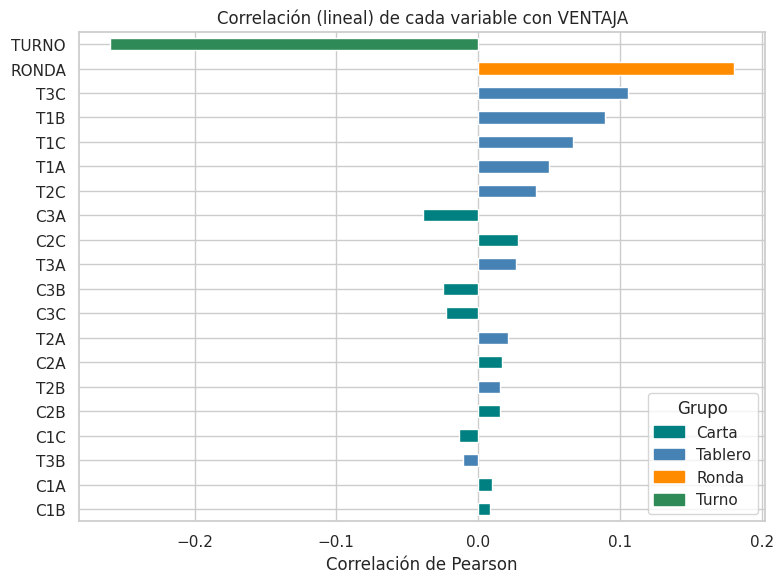

In [10]:
target_corr = df.corr(numeric_only=True)["VENTAJA"].drop("VENTAJA").sort_values(
    key=abs, ascending=False
)

bar_colors = [group_colors[group_map[var]] for var in target_corr.index]

plt.figure(figsize=(8, 6))
target_corr.plot(kind="barh", color=bar_colors)
plt.title("Correlación (lineal) de cada variable con VENTAJA")
plt.xlabel("Correlación de Pearson")
plt.gca().invert_yaxis()

handles = [plt.Rectangle((0, 0), 1, 1, color=col) for col in group_colors.values()]
plt.legend(handles, group_colors.keys(), title="Grupo", loc="lower right")

plt.tight_layout()
plt.show()

Vista agregada: correlación media absoluta con `VENTAJA` por grupo de variable.

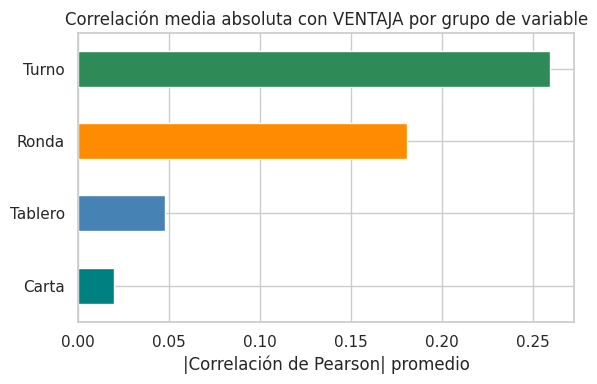

In [11]:
group_corr = (
    pd.Series({var: abs(val) for var, val in target_corr.items()})
    .groupby(group_map)
    .mean()
    .sort_values(ascending=True)
)

plt.figure(figsize=(6, 4))
group_corr.plot(kind="barh", color=[group_colors[g] for g in group_corr.index])
plt.title("Correlación media absoluta con VENTAJA por grupo de variable")
plt.xlabel("|Correlación de Pearson| promedio")
plt.tight_layout()
plt.show()

## 2. Preprocesamiento de los datos

- No hay valores faltantes ni duplicados que limpiar.
- No se escalan las variables porque Random Forest y XGBoost son invariantes a la escala
  de las features.
- No se eliminan variables por colinealidad (los modelos de árboles la toleran bien).
- **Split estratificado por `VENTAJA`**: se estratifica por la variable objetivo para que
  train y test mantengan la misma proporción de clases (hay un desbalance moderado
  ~60/40). Se verifica además que la proporción de `RONDA` no quede muy distorsionada
  entre train y test.

In [12]:
X = df[feature_cols].copy()
y = df["VENTAJA"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,   # estratificación por VENTAJA para mantener el balance de clases
)

print("Train:", X_train.shape, " Test:", X_test.shape)

print("\nProporción de VENTAJA en el dataset completo:")
print(df["VENTAJA"].value_counts(normalize=True).sort_index())

print("\nProporción de VENTAJA en train:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nProporción de VENTAJA en test:")
print(y_test.value_counts(normalize=True).sort_index())

print("\nProporción de RONDA en el dataset completo:")
print(df["RONDA"].value_counts(normalize=True).sort_index())

print("\nProporción de RONDA en train:")
print(df.loc[X_train.index, "RONDA"].value_counts(normalize=True).sort_index())

print("\nProporción de RONDA en test:")
print(df.loc[X_test.index, "RONDA"].value_counts(normalize=True).sort_index())

Train: (2325, 20)  Test: (582, 20)

Proporción de VENTAJA en el dataset completo:
VENTAJA
0    0.602683
1    0.397317
Name: proportion, dtype: float64

Proporción de VENTAJA en train:
VENTAJA
0    0.602581
1    0.397419
Name: proportion, dtype: float64

Proporción de VENTAJA en test:
VENTAJA
0    0.603093
1    0.396907
Name: proportion, dtype: float64

Proporción de RONDA en el dataset completo:
RONDA
1    0.214654
2    0.392501
3    0.209494
4    0.128655
5    0.054696
Name: proportion, dtype: float64

Proporción de RONDA en train:
RONDA
1    0.211183
2    0.397419
3    0.213763
4    0.121720
5    0.055914
Name: proportion, dtype: float64

Proporción de RONDA en test:
RONDA
1    0.228522
2    0.372852
3    0.192440
4    0.156357
5    0.049828
Name: proportion, dtype: float64


In [13]:
# Copia independiente del set de entrenamiento y de test para no afectar
# el pipeline de los modelos de árboles (Random Forest / XGBoost)
X_train_lr = X_train.copy()
X_test_lr = X_test.copy()

# El escalador se ajusta SOLO con train
scaler = StandardScaler()
X_train_lr = pd.DataFrame(
    scaler.fit_transform(X_train_lr),
    columns=X_train_lr.columns,
    index=X_train_lr.index,
)

print("X_train_lr:", X_train_lr.shape)
X_train_lr.describe().T[["mean", "std"]]

X_train_lr: (2325, 20)


,mean,std
C1A,-3.972927e-17,1.000215
C1B,-5.959391e-17,1.000215
C1C,-1.833659e-17,1.000215
C2A,1.451646e-17,1.000215
C2B,-6.265000e-17,1.000215
C2C,7.640244e-19,1.000215
C3A,-6.723415e-17,1.000215
C3B,0.000000e+00,1.000215
C3C,-8.404269e-18,1.000215
T1A,3.056098e-17,1.000215


Para la validación cruzada se usa `StratifiedKFold`, preservando la proporción de
clases en cada fold. Esta misma partición de folds se reutiliza en la sección 3 (para
seleccionar el modelo ganador) y en la sección 4 (para el tuning), de forma que ambas
etapas sean comparables entre sí.

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

## 3. Entrenamiento de los modelos (validación cruzada)

Se entrenan dos modelos candidatos (parámetros por defecto / razonables, sin tuning todavía):

- `RandomForestClassifier`
- `XGBClassifier`

Como baselines de referencia se usan un `DummyClassifier` (predice siempre la clase mayoritaria) y una `LogisticRegression`.

In [15]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

baseline_models = {
    "Dummy (clase mayoritaria)": DummyClassifier(strategy="most_frequent"),
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
}

models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1,
        eval_metric="logloss",
    ),
}

def print_cv_summary(name, res):
    print(f"--- {name} (CV 5-fold estratificada sobre train) ---")
    print(f"Accuracy : {res['test_accuracy'].mean():.4f} +/- {res['test_accuracy'].std():.4f}")
    print(f"Precision: {res['test_precision'].mean():.4f} +/- {res['test_precision'].std():.4f}")
    print(f"Recall   : {res['test_recall'].mean():.4f} +/- {res['test_recall'].std():.4f}")
    print(f"F1       : {res['test_f1'].mean():.4f} +/- {res['test_f1'].std():.4f}")
    print(f"ROC-AUC  : {res['test_roc_auc'].mean():.4f} +/- {res['test_roc_auc'].std():.4f}")

baseline_cv_results = {}
for name, model in baseline_models.items():
    if(name == "LogisticRegression"):
        res = cross_validate(model, X_train_lr, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    else:
        res = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    baseline_cv_results[name] = res
    print_cv_summary(name, res)

cv_results = {}
for name, model in models.items():
    res = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[name] = res
    print_cv_summary(name, res)

--- Dummy (clase mayoritaria) (CV 5-fold estratificada sobre train) ---
Accuracy : 0.6026 +/- 0.0009
Precision: 0.0000 +/- 0.0000
Recall   : 0.0000 +/- 0.0000
F1       : 0.0000 +/- 0.0000
ROC-AUC  : 0.5000 +/- 0.0000
--- LogisticRegression (CV 5-fold estratificada sobre train) ---
Accuracy : 0.6318 +/- 0.0203
Precision: 0.5537 +/- 0.0381
Recall   : 0.3798 +/- 0.0509
F1       : 0.4491 +/- 0.0425
ROC-AUC  : 0.6569 +/- 0.0418
--- RandomForest (CV 5-fold estratificada sobre train) ---
Accuracy : 0.7738 +/- 0.0217
Precision: 0.7481 +/- 0.0359
Recall   : 0.6504 +/- 0.0269
F1       : 0.6957 +/- 0.0287
ROC-AUC  : 0.8385 +/- 0.0243
--- XGBoost (CV 5-fold estratificada sobre train) ---
Accuracy : 0.8013 +/- 0.0237
Precision: 0.7599 +/- 0.0277
Recall   : 0.7305 +/- 0.0405
F1       : 0.7447 +/- 0.0330
ROC-AUC  : 0.8733 +/- 0.0166


In [16]:
cv_all_results = {**baseline_cv_results, **cv_results}

cv_summary = {
    name: {
        "Accuracy": res["test_accuracy"].mean(),
        "Precision": res["test_precision"].mean(),
        "Recall": res["test_recall"].mean(),
        "F1": res["test_f1"].mean(),
        "ROC_AUC": res["test_roc_auc"].mean(),
    }
    for name, res in cv_all_results.items()
}
cv_summary_df = pd.DataFrame(cv_summary).T
cv_summary_df

,Accuracy,Precision,Recall,F1,ROC_AUC
Dummy (clase mayoritaria),0.602581,0.000000,0.000000,0.000000,0.500000
LogisticRegression,0.631828,0.553669,0.379841,0.449146,0.656929
RandomForest,0.773763,0.748079,0.650441,0.695658,0.838544
XGBoost,0.801290,0.759881,0.730482,0.744679,0.873279


### 3.1 Comparación por métrica (validación cruzada)

Un gráfico de barras por métrica, comparando los 4 modelos (baselines + candidatos) según
su desempeño promedio en la validación cruzada.

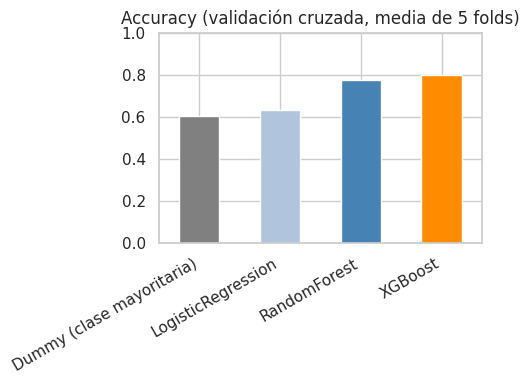

In [17]:
fig, ax = plt.subplots(figsize=(5, 4))
colors = ["gray", "lightsteelblue", "steelblue", "darkorange"]  # Dummy, Logistic, RF, XGBoost

cv_summary_df["Accuracy"].plot(kind="bar", ax=ax, color=colors)
ax.set_title("Accuracy (validación cruzada, media de 5 folds)")
ax.set_ylim(0, 1)
ax.set_xticklabels(cv_summary_df.index, rotation=30, ha="right")

plt.tight_layout()
plt.show()

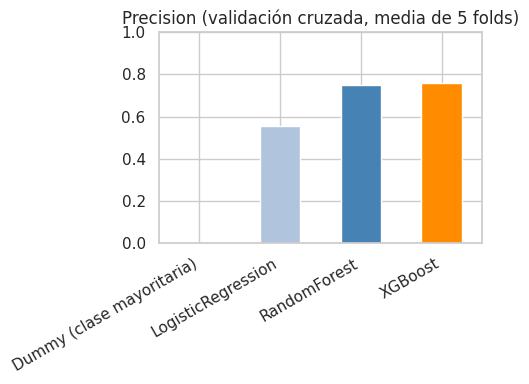

In [18]:
fig, ax = plt.subplots(figsize=(5, 4))
colors = ["gray", "lightsteelblue", "steelblue", "darkorange"]  # Dummy, Logistic, RF, XGBoost

cv_summary_df["Precision"].plot(kind="bar", ax=ax, color=colors)
ax.set_title("Precision (validación cruzada, media de 5 folds)")
ax.set_ylim(0, 1)
ax.set_xticklabels(cv_summary_df.index, rotation=30, ha="right")

plt.tight_layout()
plt.show()

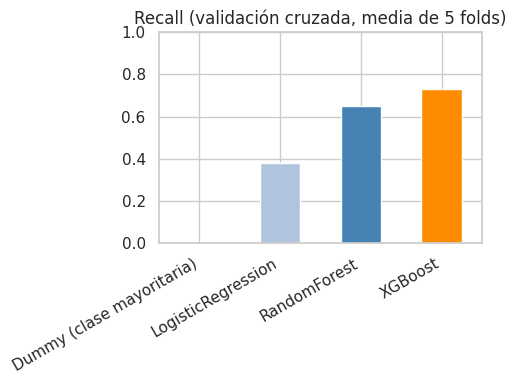

In [19]:
fig, ax = plt.subplots(figsize=(5, 4))
colors = ["gray", "lightsteelblue", "steelblue", "darkorange"]  # Dummy, Logistic, RF, XGBoost

cv_summary_df["Recall"].plot(kind="bar", ax=ax, color=colors)
ax.set_title("Recall (validación cruzada, media de 5 folds)")
ax.set_ylim(0, 1)
ax.set_xticklabels(cv_summary_df.index, rotation=30, ha="right")

plt.tight_layout()
plt.show()

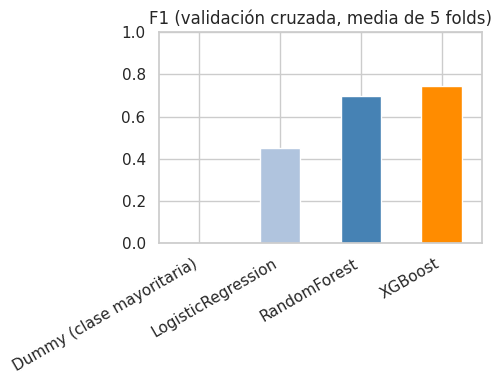

In [20]:
fig, ax = plt.subplots(figsize=(5, 4))
colors = ["gray", "lightsteelblue", "steelblue", "darkorange"]  # Dummy, Logistic, RF, XGBoost

cv_summary_df["F1"].plot(kind="bar", ax=ax, color=colors)
ax.set_title("F1 (validación cruzada, media de 5 folds)")
ax.set_ylim(0, 1)
ax.set_xticklabels(cv_summary_df.index, rotation=30, ha="right")

plt.tight_layout()
plt.show()

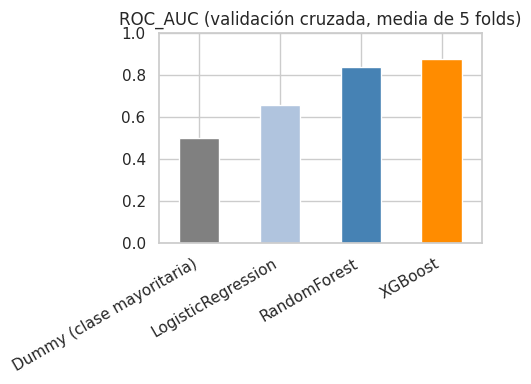

In [21]:
fig, ax = plt.subplots(figsize=(5, 4))
colors = ["gray", "lightsteelblue", "steelblue", "darkorange"]  # Dummy, Logistic, RF, XGBoost

cv_summary_df["ROC_AUC"].plot(kind="bar", ax=ax, color=colors)
ax.set_title("ROC_AUC (validación cruzada, media de 5 folds)")
ax.set_ylim(0, 1)
ax.set_xticklabels(cv_summary_df.index, rotation=30, ha="right")

plt.tight_layout()
plt.show()

## 4. Ajuste de hiperparámetros: Random Forest vs XGBoost

Se realiza una búsqueda de hiperparámetros con `RandomizedSearchCV` (más eficiente que un `GridSearchCV` exhaustivo dado el tamaño del espacio de búsqueda), usando el mismo `StratifiedKFold` de 5 particiones sobre el set de entrenamiento y ROC-AUC como métrica objetivo.

### 4.1 Primer ajuste fino

In [22]:
param_distributions_xgb = {
    "n_estimators": [200, 300, 500, 800],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [1, 1.5, 2, 5],
}
base_estimator_xgb = XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1, eval_metric="logloss")

In [23]:
search_xgb = RandomizedSearchCV(
    estimator=base_estimator_xgb,
    param_distributions=param_distributions_xgb,
    n_iter=50,
    scoring="roc_auc",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

In [24]:
search_xgb.fit(X_train, y_train)

print("Mejor ROC-AUC en CV:", search_xgb.best_score_)
print("Mejores hiperparámetros:")
search_xgb.best_params_

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Mejor ROC-AUC en CV: 0.8759177760904514
Mejores hiperparámetros:


{'subsample': 0.8,
 'reg_lambda': 1.5,
 'reg_alpha': 0,
 'n_estimators': 800,
 'min_child_weight': 3,
 'max_depth': 8,
 'learning_rate': 0.1,
 'colsample_bytree': 0.6}

In [25]:
tuned_xgb = search_xgb.best_estimator_

In [26]:
param_distributions_rf = {
    "n_estimators": [200, 300, 500, 800],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.5, None],
}
base_estimator_rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

In [27]:
search_rf = RandomizedSearchCV(
    estimator=base_estimator_rf,
    param_distributions=param_distributions_rf,
    n_iter=50,
    scoring="roc_auc",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

In [28]:
search_rf.fit(X_train, y_train)

print("Mejor ROC-AUC en CV:", search_rf.best_score_)
print("Mejores hiperparámetros:")
search_rf.best_params_

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Mejor ROC-AUC en CV: 0.8410581632781076
Mejores hiperparámetros:


{'n_estimators': 800,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 'log2',
 'max_depth': None}

In [29]:
tuned_rf = search_rf.best_estimator_

In [30]:
searches = {}
searches["XGBoost"] = search_xgb
searches["RandomForest"] = search_rf
tuned_estimators = {"XGBoost": tuned_xgb, "RandomForest": tuned_rf}

In [31]:
param_distributions = {
    "XGBoost": param_distributions_xgb,
    "RandomForest": param_distributions_rf,
}

### 4.2 Primer análisis de sensibilidad

In [32]:
def build_search_results_df(search, model_name):
    df = pd.DataFrame(search.cv_results_)
    param_cols = [c for c in df.columns if c.startswith("param_")]
    df = df[param_cols + ["mean_test_score", "std_test_score", "rank_test_score"]].copy()
    df.columns = [c.replace("param_", "") for c in df.columns]
    df.insert(0, "model", model_name)
    return df

In [33]:
search_results = {name: build_search_results_df(s, name) for name, s in searches.items()}

In [34]:
def sensitivity_index(df_res, param_cols):
    rows = []
    total_var = df_res["mean_test_score"].var()
    for p in param_cols:
        medias_por_valor = df_res.groupby(p)["mean_test_score"].mean()
        rows.append({
            "hiperparametro": p,
            "rango_score": medias_por_valor.max() - medias_por_valor.min(),
            "var_explicada_aprox": medias_por_valor.var() / total_var if total_var > 0 else float("nan"),
        })
    return pd.DataFrame(rows).sort_values("var_explicada_aprox", ascending=False)

In [35]:
for name, df_res in search_results.items():
    param_cols = [c for c in df_res.columns if c not in ("model", "mean_test_score", "std_test_score", "rank_test_score")]
    print(f"--- Sensibilidad aproximada — {name} ---")
    print(sensitivity_index(df_res, param_cols))

--- Sensibilidad aproximada — XGBoost ---
     hiperparametro  rango_score  var_explicada_aprox
6     learning_rate     0.072504             0.518359
5         max_depth     0.057388             0.302416
2         reg_alpha     0.037131             0.153637
7  colsample_bytree     0.027445             0.152128
0         subsample     0.024911             0.109171
3      n_estimators     0.020137             0.057085
1        reg_lambda     0.015242             0.029661
4  min_child_weight     0.011158             0.020540
--- Sensibilidad aproximada — RandomForest ---
      hiperparametro  rango_score  var_explicada_aprox
4          max_depth     0.079415             1.856706
3       max_features     0.019891             0.145094
1  min_samples_split     0.014229             0.079576
0       n_estimators     0.015062             0.071171
2   min_samples_leaf     0.011148             0.043286


### 4.3 Evaluación de hiperparámetros

In [36]:
for name, s in searches.items():
    print(f"--- {name}: mejores hiperparámetros vs. límites de la grilla ---")
    for p, v in s.best_params_.items():
        grid = param_distributions[name][p]
        # si el valor ganador es el min o max de la grilla, marcarlo
        en_borde = (v == min(grid, key=lambda x: (x is None, x)) or v == max(grid, key=lambda x: (x is None, x))) if all(isinstance(x, (int, float)) or x is None for x in grid) else False
        flag = " ⚠️ EN EL BORDE" if en_borde else ""
        print(f"  {p}: {v}{flag}")

--- XGBoost: mejores hiperparámetros vs. límites de la grilla ---
  subsample: 0.8
  reg_lambda: 1.5
  reg_alpha: 0 ⚠️ EN EL BORDE
  n_estimators: 800 ⚠️ EN EL BORDE
  min_child_weight: 3
  max_depth: 8 ⚠️ EN EL BORDE
  learning_rate: 0.1
  colsample_bytree: 0.6 ⚠️ EN EL BORDE
--- RandomForest: mejores hiperparámetros vs. límites de la grilla ---
  n_estimators: 800 ⚠️ EN EL BORDE
  min_samples_split: 2 ⚠️ EN EL BORDE
  min_samples_leaf: 1 ⚠️ EN EL BORDE
  max_features: log2
  max_depth: None ⚠️ EN EL BORDE


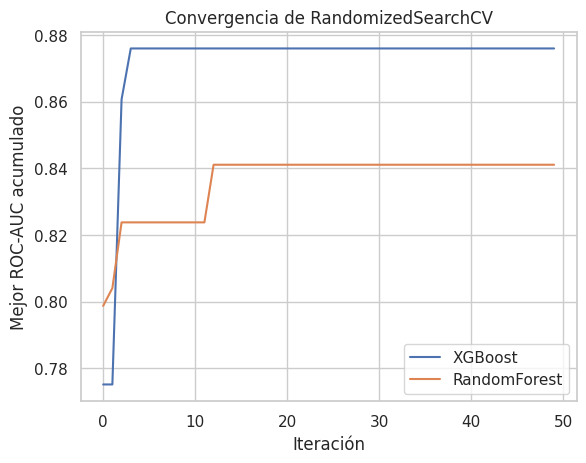

In [37]:
for name, s in searches.items():
    scores = pd.Series(s.cv_results_["mean_test_score"])
    running_best = scores.cummax()
    plt.plot(running_best.values, label=name)
plt.xlabel("Iteración")
plt.ylabel("Mejor ROC-AUC acumulado")
plt.title("Convergencia de RandomizedSearchCV")
plt.legend()
plt.show()

### 4.4 Segundo ajuste fino

In [38]:
param_distributions_xgb = {
    "n_estimators": [800, 1500, 2000, 2500, 3000],
    "max_depth": [8, 10],
    "learning_rate": [0.07, 0.08, 0.1],
    "colsample_bytree": [0.5, 0.6, 0.7],
    "subsample": [0.8],
    "min_child_weight": [3],
    "reg_alpha": [0, 0.02, 0.05],
    "reg_lambda": [1.5, 2.5, 3, 3.5],
}
base_estimator_xgb = XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1, eval_metric="logloss")

In [39]:
search_xgb = RandomizedSearchCV(
    estimator=base_estimator_xgb,
    param_distributions=param_distributions_xgb,
    n_iter=20,
    scoring="roc_auc",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

In [40]:
search_xgb.fit(X_train, y_train)

print("Mejor ROC-AUC en CV:", search_xgb.best_score_)
print("Mejores hiperparámetros:")
search_xgb.best_params_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejor ROC-AUC en CV: 0.8784783098564624
Mejores hiperparámetros:


{'subsample': 0.8,
 'reg_lambda': 1.5,
 'reg_alpha': 0.05,
 'n_estimators': 800,
 'min_child_weight': 3,
 'max_depth': 10,
 'learning_rate': 0.08,
 'colsample_bytree': 0.6}

In [41]:
tuned_xgb = search_xgb.best_estimator_

In [42]:
param_distributions_rf = {
    "n_estimators": [800, 1000, 1500, 2000, 2500],
    "max_depth": [None],
    "min_samples_split": [2],
    "min_samples_leaf": [1],
    "max_features": ["sqrt", "log2", 0.4, 0.5],
}
base_estimator_rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

In [43]:
search_rf = RandomizedSearchCV(
    estimator=base_estimator_rf,
    param_distributions=param_distributions_rf,
    n_iter=20,
    scoring="roc_auc",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

In [44]:
search_rf.fit(X_train, y_train)

print("Mejor ROC-AUC en CV:", search_rf.best_score_)
print("Mejores hiperparámetros:")
search_rf.best_params_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejor ROC-AUC en CV: 0.8426729195653071
Mejores hiperparámetros:


{'n_estimators': 2000,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': None}

In [45]:
tuned_rf = search_rf.best_estimator_

In [46]:
searches = {}
searches["XGBoost"] = search_xgb
searches["RandomForest"] = search_rf
tuned_estimators = {"XGBoost": tuned_xgb, "RandomForest": tuned_rf}

In [47]:
param_distributions = {
    "XGBoost": param_distributions_xgb,
    "RandomForest": param_distributions_rf,
}

### 4.5 Segundo análisis de sensibilidad

In [48]:
def build_search_results_df(search, model_name):
    df = pd.DataFrame(search.cv_results_)
    param_cols = [c for c in df.columns if c.startswith("param_")]
    df = df[param_cols + ["mean_test_score", "std_test_score", "rank_test_score"]].copy()
    df.columns = [c.replace("param_", "") for c in df.columns]
    df.insert(0, "model", model_name)
    return df

In [49]:
search_results = {name: build_search_results_df(s, name) for name, s in searches.items()}

In [50]:
def sensitivity_index(df_res, param_cols):
    rows = []
    total_var = df_res["mean_test_score"].var()
    for p in param_cols:
        medias_por_valor = df_res.groupby(p)["mean_test_score"].mean()
        rows.append({
            "hiperparametro": p,
            "rango_score": medias_por_valor.max() - medias_por_valor.min(),
            "var_explicada_aprox": medias_por_valor.var() / total_var if total_var > 0 else float("nan"),
        })
    return pd.DataFrame(rows).sort_values("var_explicada_aprox", ascending=False)

In [51]:
for name, df_res in search_results.items():
    param_cols = [c for c in df_res.columns if c not in ("model", "mean_test_score", "std_test_score", "rank_test_score")]
    print(f"--- Sensibilidad aproximada — {name} ---")
    print(sensitivity_index(df_res, param_cols))

--- Sensibilidad aproximada — XGBoost ---
     hiperparametro  rango_score  var_explicada_aprox
1        reg_lambda     0.001709             0.607913
6     learning_rate     0.001295             0.446838
2         reg_alpha     0.000910             0.281511
3      n_estimators     0.000836             0.114722
7  colsample_bytree     0.000530             0.083651
5         max_depth     0.000005             0.000012
0         subsample     0.000000                  NaN
4  min_child_weight     0.000000                  NaN
--- Sensibilidad aproximada — RandomForest ---
      hiperparametro  rango_score  var_explicada_aprox
3       max_features     0.008531             1.237442
0       n_estimators     0.001216             0.022644
1  min_samples_split     0.000000                  NaN
2   min_samples_leaf     0.000000                  NaN
4          max_depth          NaN                  NaN


In [52]:
for name, s in searches.items():
    print(f"--- {name}: mejores hiperparámetros vs. límites de la grilla ---")
    for p, v in s.best_params_.items():
        grid = param_distributions[name][p]
        # si el valor ganador es el min o max de la grilla, marcarlo
        en_borde = (v == min(grid, key=lambda x: (x is None, x)) or v == max(grid, key=lambda x: (x is None, x))) if all(isinstance(x, (int, float)) or x is None for x in grid) else False
        flag = " ⚠️ EN EL BORDE" if en_borde else ""
        print(f"  {p}: {v}{flag}")

--- XGBoost: mejores hiperparámetros vs. límites de la grilla ---
  subsample: 0.8 ⚠️ EN EL BORDE
  reg_lambda: 1.5 ⚠️ EN EL BORDE
  reg_alpha: 0.05 ⚠️ EN EL BORDE
  n_estimators: 800 ⚠️ EN EL BORDE
  min_child_weight: 3 ⚠️ EN EL BORDE
  max_depth: 10 ⚠️ EN EL BORDE
  learning_rate: 0.08
  colsample_bytree: 0.6
--- RandomForest: mejores hiperparámetros vs. límites de la grilla ---
  n_estimators: 2000
  min_samples_split: 2 ⚠️ EN EL BORDE
  min_samples_leaf: 1 ⚠️ EN EL BORDE
  max_features: sqrt
  max_depth: None ⚠️ EN EL BORDE


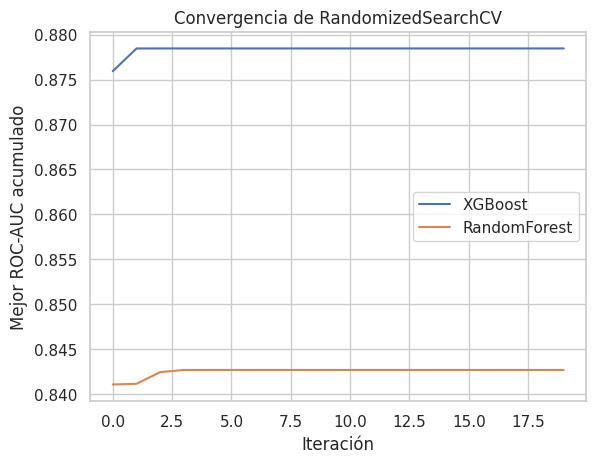

In [53]:
for name, s in searches.items():
    scores = pd.Series(s.cv_results_["mean_test_score"])
    running_best = scores.cummax()
    plt.plot(running_best.values, label=name)
plt.xlabel("Iteración")
plt.ylabel("Mejor ROC-AUC acumulado")
plt.title("Convergencia de RandomizedSearchCV")
plt.legend()
plt.show()

### 4.6 Comparación de los modelos tuneados (validación cruzada)

Se recalculan las 5 métricas (accuracy, precision, recall, f1, roc_auc) con validación cruzada estratificada de 5 folds sobre el set de entrenamiento, usando en cada caso el mejor estimador encontrado por `RandomizedSearchCV`.

In [54]:
tuned_cv_results = {}
for name, estimator in tuned_estimators.items():
    res = cross_validate(estimator, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    tuned_cv_results[name] = res
    print_cv_summary(f"{name} (tuneado)", res)

tuned_cv_summary = {
    name: {
        "Accuracy": res["test_accuracy"].mean(),
        "Precision": res["test_precision"].mean(),
        "Recall": res["test_recall"].mean(),
        "F1": res["test_f1"].mean(),
        "ROC_AUC": res["test_roc_auc"].mean(),
        "ROC_AUC_std": res["test_roc_auc"].std(),
    }
    for name, res in tuned_cv_results.items()
}

--- XGBoost (tuneado) (CV 5-fold estratificada sobre train) ---
Accuracy : 0.8108 +/- 0.0159
Precision: 0.7831 +/- 0.0255
Recall   : 0.7251 +/- 0.0189
F1       : 0.7529 +/- 0.0200
ROC-AUC  : 0.8785 +/- 0.0175
--- RandomForest (tuneado) (CV 5-fold estratificada sobre train) ---
Accuracy : 0.7729 +/- 0.0182
Precision: 0.7481 +/- 0.0318
Recall   : 0.6472 +/- 0.0207
F1       : 0.6938 +/- 0.0231
ROC-AUC  : 0.8427 +/- 0.0240


In [55]:
tuned_cv_summary_df = pd.DataFrame(tuned_cv_summary).T
tuned_cv_summary_df

,Accuracy,Precision,Recall,F1,ROC_AUC,ROC_AUC_std
XGBoost,0.810753,0.783093,0.725082,0.752851,0.878478,0.017474
RandomForest,0.772903,0.748147,0.647197,0.693834,0.842673,0.023980


#### 4.6.1 Matrices de confusión

In [56]:
oof_preds = {}
oof_probas = {}
for name, estimator in tuned_estimators.items():
    oof_preds[name] = cross_val_predict(estimator, X_train, y_train, cv=cv, method="predict")
    oof_probas[name] = cross_val_predict(estimator, X_train, y_train, cv=cv, method="predict_proba")[:, 1]

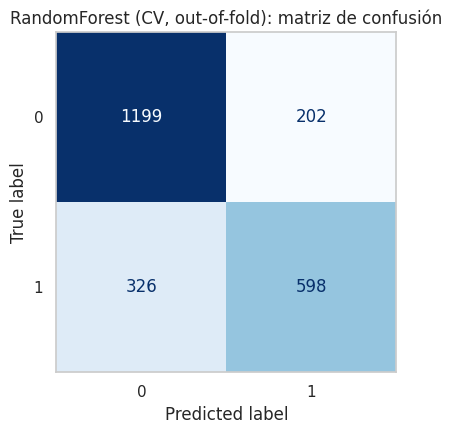

In [57]:
name_rf = "RandomForest"

fig, ax = plt.subplots(figsize=(5, 4.5))
cm_rf = confusion_matrix(y_train, oof_preds[name_rf])
ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["0", "1"]).plot(
    ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title(f"{name_rf} (CV, out-of-fold): matriz de confusión")
ax.grid(False)

plt.tight_layout()
plt.show()

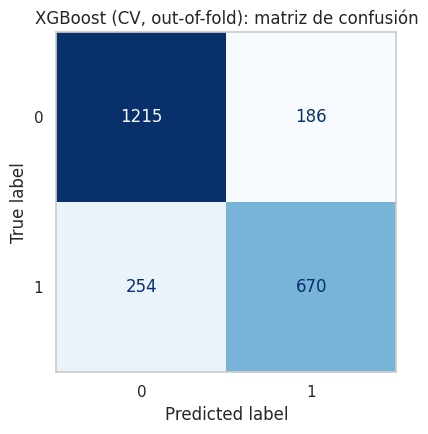

In [58]:
name_xgb = "XGBoost"

fig, ax = plt.subplots(figsize=(5, 4.5))
cm_xgb = confusion_matrix(y_train, oof_preds[name_xgb])
ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=["0", "1"]).plot(
    ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title(f"{name_xgb} (CV, out-of-fold): matriz de confusión")
ax.grid(False)

plt.tight_layout()
plt.show()

#### 4.6.2 Curva ROC

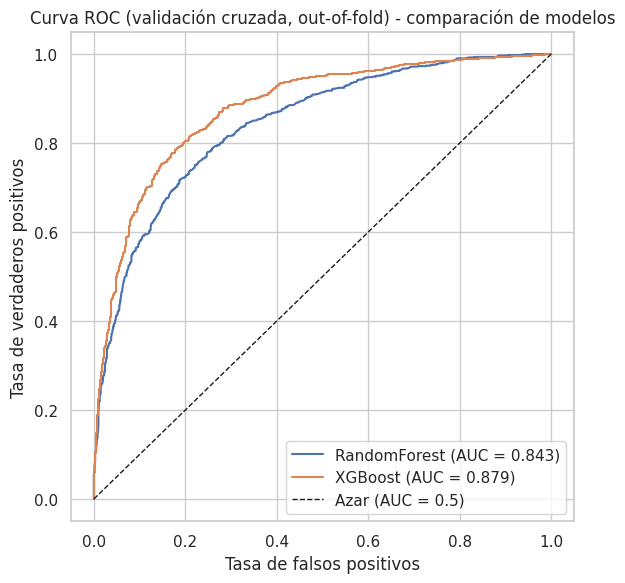

In [59]:
plt.figure(figsize=(6, 6))
for name in models:
    fpr, tpr, _ = roc_curve(y_train, oof_probas[name])
    auc = roc_auc_score(y_train, oof_probas[name])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Azar (AUC = 0.5)")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC (validación cruzada, out-of-fold) - comparación de modelos")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Selección y evaluación del modelo ganador

### 5.1 Selección del modelo ganador

In [60]:
best_model_name = tuned_cv_summary_df["ROC_AUC"].idxmax()
tuned_model = tuned_estimators[best_model_name]

print(f"Modelo ganador tras el tuning (según ROC-AUC promedio en CV): {best_model_name}")
tuned_cv_summary_df.loc[[best_model_name]]

Modelo ganador tras el tuning (según ROC-AUC promedio en CV): XGBoost


,Accuracy,Precision,Recall,F1,ROC_AUC,ROC_AUC_std
XGBoost,0.810753,0.783093,0.725082,0.752851,0.878478,0.017474


### 5.2 Evaluación del modelo tuneado (set de test)

Primer y único uso del set de test en todo el notebook.

In [61]:
def evaluate(model, X_te, y_te):
    preds = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]
    return {
        "Accuracy": accuracy_score(y_te, preds),
        "Precision": precision_score(y_te, preds, zero_division=0),
        "Recall": recall_score(y_te, preds, zero_division=0),
        "F1": f1_score(y_te, preds, zero_division=0),
        "ROC_AUC": roc_auc_score(y_te, proba),
    }

In [62]:
tuned_metrics = evaluate(tuned_model, X_test, y_test)

print(f"Métricas del modelo {best_model_name} tuneado (test):")
for metric_name, value in tuned_metrics.items():
    print(f"  {metric_name:9s}: {value:.4f}")

Métricas del modelo XGBoost tuneado (test):
  Accuracy : 0.8333
  Precision: 0.8284
  Recall   : 0.7316
  F1       : 0.7770
  ROC_AUC  : 0.9140


### 5.3 Matriz de confusión y curva ROC del modelo final (test)

In [63]:
preds_tuned = tuned_model.predict(X_test)
proba_tuned = tuned_model.predict_proba(X_test)[:, 1]

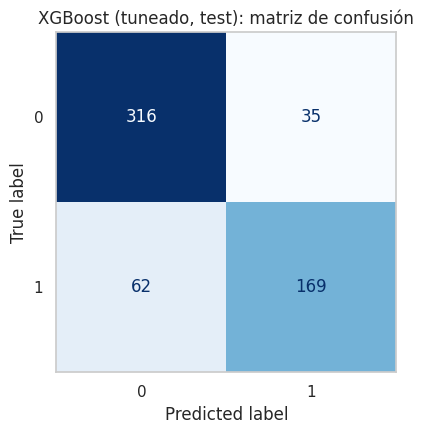

In [64]:
fig, ax = plt.subplots(figsize=(5, 4.5))

cm = confusion_matrix(y_test, preds_tuned)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"]).plot(
    ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title(f"{best_model_name} (tuneado, test): matriz de confusión")
ax.grid(False)

plt.tight_layout()
plt.show()

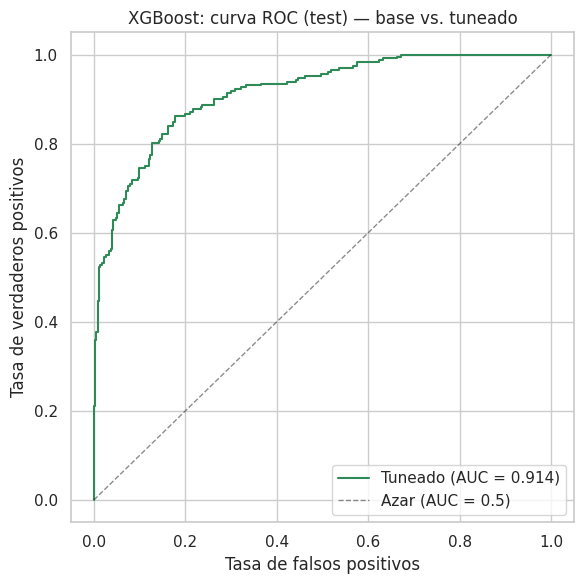

In [65]:
fig, ax = plt.subplots(figsize=(6, 6))

fpr, tpr, _ = roc_curve(y_test, proba_tuned)
auc = roc_auc_score(y_test, proba_tuned)
ax.plot(fpr, tpr, color="seagreen", label=f"Tuneado (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Azar (AUC = 0.5)")
ax.set_xlabel("Tasa de falsos positivos")
ax.set_ylabel("Tasa de verdaderos positivos")
ax.set_title(f"{best_model_name}: curva ROC (test) — base vs. tuneado")
ax.legend()

plt.tight_layout()
plt.show()

In [66]:
# Guardar el modelo final (opcional)
import joblib
joblib.dump(tuned_model, "modelo_final_ventaja.pkl")
print("Modelo guardado en modelo_final_ventaja.pkl")

Modelo guardado en modelo_final_ventaja.pkl


## 6. Interpretabilidad con SHAP (modelo tuneado)

`feature_importances_` reparte el crédito de forma algo arbitraria cuando hay variables correlacionadas (recordar la multicolinealidad documentada entre las variables `T*` en el EDA). SHAP (SHapley Additive exPlanations) da una explicación más consistente:

- Es **aditivo**: la suma de los SHAP values de una fila más el valor base reconstruye exactamente el logit (o la probabilidad, según la convención del explainer) de `VENTAJA=1` para esa fila.
- Muestra **dirección** del efecto (si un valor alto de la variable empuja la probabilidad de `VENTAJA=1` hacia arriba o hacia abajo), no solo cuánto "importa" en promedio.
- Permite explicaciones tanto **globales** (todo el dataset) como **locales** (una jugada puntual).

Se usa `TreeExplainer`, que es exacto y eficiente para modelos basados en árboles como Random Forest y XGBoost. Para clasificación binaria, según la versión de SHAP y del modelo, el explainer puede devolver los valores para ambas clases; se normaliza para quedarnos siempre con los SHAP values de la clase positiva (`VENTAJA=1`).

In [67]:
explainer = shap.TreeExplainer(tuned_model)
shap_values = explainer(X_test)

# Para clasificación binaria, algunos modelos/backends devuelven un array
# (n_muestras, n_features, n_clases); nos quedamos con la clase positiva (VENTAJA=1).
if shap_values.values.ndim == 3:
    shap_values = shap_values[..., 1]

print("Shape de shap_values.values:", shap_values.values.shape)

Shape de shap_values.values: (582, 20)


### 6.1 Importancia global de variables (SHAP), agrupada por carta/tablero/ronda/turno

In [68]:
sum_abs_shap = pd.Series(np.abs(shap_values.values).sum(axis=0), index=feature_cols)
group_shap = sum_abs_shap.groupby(group_map).sum().sort_values(ascending=False)
group_shap

,0
Tablero,1633.065796
Carta,1479.464966
Turno,445.610046
Ronda,197.104233


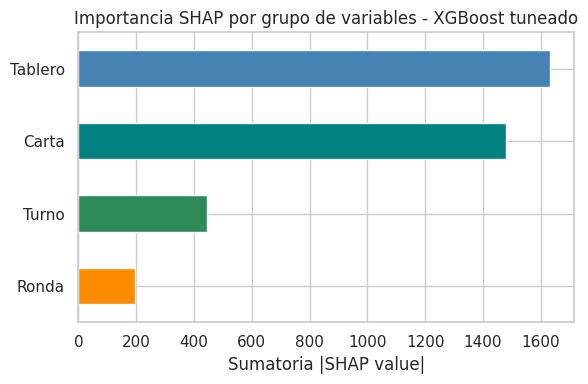

In [69]:
group_shap = sum_abs_shap.groupby(group_map).sum().sort_values(ascending=True)

plt.figure(figsize=(6, 4))
group_shap.plot(kind="barh", color=[group_colors[g] for g in group_shap.index])
plt.title(f"Importancia SHAP por grupo de variables - {best_model_name} tuneado")
plt.xlabel("Sumatoria |SHAP value|")
plt.tight_layout()
plt.show()

In [70]:
sum_abs_shap_sorted = sum_abs_shap.sort_values(ascending=False)
sum_abs_shap_sorted

,0
TURNO,445.610046
T1B,227.275131
T2B,212.985184
C2B,204.939926
T3A,197.171341
RONDA,197.104233
C3B,188.459732
C2A,188.361710
T1C,187.362381
T3C,186.360580


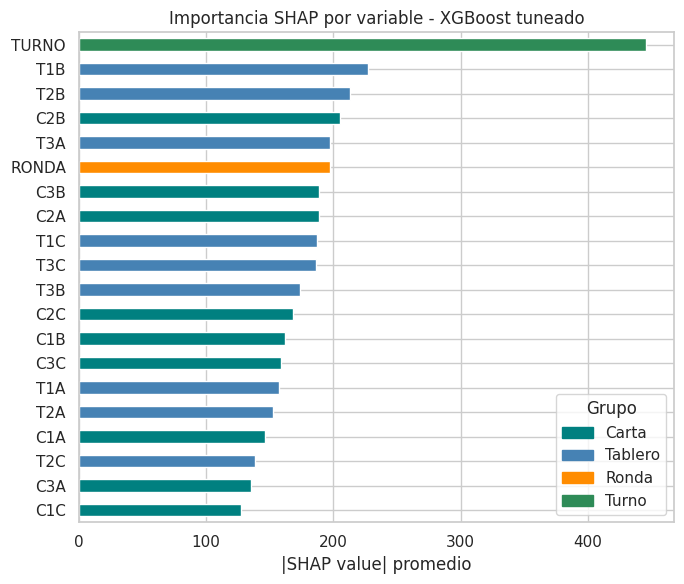

In [71]:
mean_abs_shap_sorted = sum_abs_shap.sort_values(ascending=True)
bar_colors_shap = [group_colors[group_map[var]] for var in mean_abs_shap_sorted.index]

plt.figure(figsize=(7, 6))
mean_abs_shap_sorted.plot(kind="barh", color=bar_colors_shap)
plt.title(f"Importancia SHAP por variable - {best_model_name} tuneado")
plt.xlabel("|SHAP value| promedio")

handles = [plt.Rectangle((0, 0), 1, 1, color=col) for col in group_colors.values()]
plt.legend(handles, group_colors.keys(), title="Grupo", loc="lower right")

plt.tight_layout()
plt.show()

### 6.2 Distribución e impacto por variable (SHAP summary plot - beeswarm)

Cada punto es una fila del set de test. La posición en el eje X indica si esa variable
empujó la predicción hacia `VENTAJA=1` o hacia `VENTAJA=0` para esa fila, y el color
indica si el valor de la variable era alto (rojo) o bajo (azul).

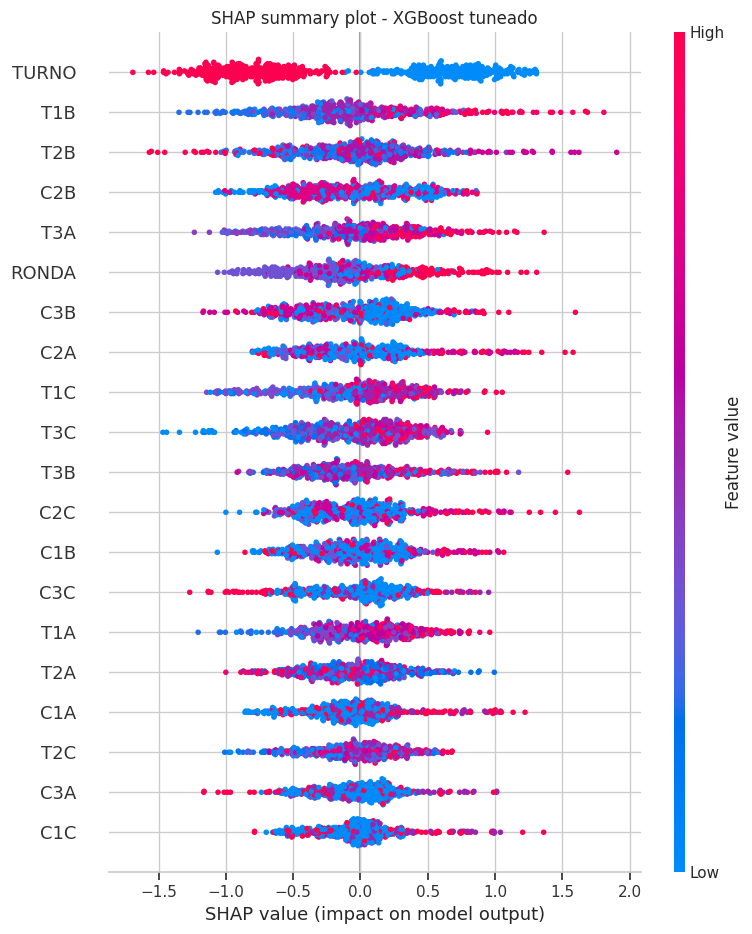

In [72]:
shap.summary_plot(shap_values, X_test, show=False)
plt.title(f"SHAP summary plot - {best_model_name} tuneado")
plt.tight_layout()
plt.show()

### 6.3 Dependence plots de las variables más importantes

Se inspeccionan con más detalle las variables que resultaron más influyentes, viendo cómo
el SHAP value de cada una varía según su propio valor y, opcionalmente, coloreado por una
segunda variable con la que pueda interactuar.

Top 3 variables según SHAP: ['TURNO', 'T1B', 'T2B']


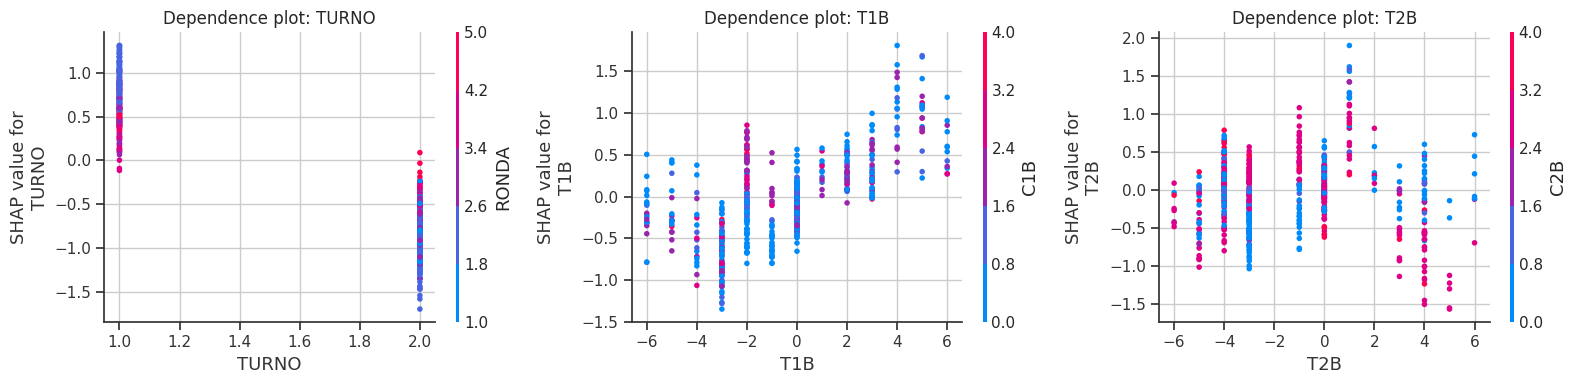

In [73]:
top_features = (
    pd.Series(np.abs(shap_values.values).mean(axis=0), index=feature_cols)
    .sort_values(ascending=False)
    .head(3)
    .index.tolist()
)
print("Top 3 variables según SHAP:", top_features)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, feat in zip(axes, top_features):
    shap.dependence_plot(feat, shap_values.values, X_test, ax=ax, show=False)
    ax.set_title(f"Dependence plot: {feat}")
plt.tight_layout()
plt.show()

### 6.4 Explicación local de un caso puntual

Ejemplo de cómo SHAP explica la predicción de una jugada individual del set de test: qué
variables la empujaron hacia `VENTAJA=1` o hacia `VENTAJA=0` respecto al valor base.

VENTAJA real: 1
Probabilidad predicha de VENTAJA=1: 0.9753
Clase predicha: 1


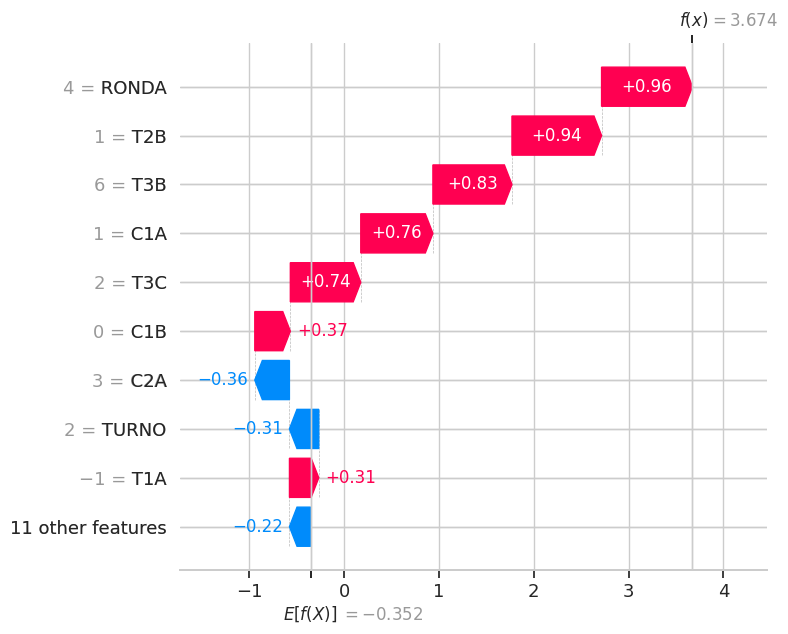

In [74]:
idx = 0  # cambiar el índice para inspeccionar otra jugada del set de test
proba_idx = tuned_model.predict_proba(X_test.iloc[[idx]])[0, 1]
print(f"VENTAJA real: {y_test.iloc[idx]}")
print(f"Probabilidad predicha de VENTAJA=1: {proba_idx:.4f}")
print(f"Clase predicha: {int(proba_idx >= 0.5)}")

shap.plots.waterfall(shap_values[idx], show=False)
plt.tight_layout()
plt.show()

### Conclusiones

- El modelo ganador se eligió con validación cruzada (sección 3), sin usar el set de
  test; el test solo se usó una vez, para confirmar el desempeño del modelo ya tuneado
  (sección 4).
- Al ser `VENTAJA` una variable binaria con desbalance moderado (~60/40), ROC-AUC y F1 son
  más informativas que accuracy para juzgar el desempeño real del modelo.
- Antes de llevar el modelo a producción, se recomienda:
  1. Repetir esta evaluación con más partidas simuladas, en particular de rondas 4 y 5,
     para confirmar que el desempeño se mantiene en esa región poco representada.
  2. Revisar el umbral de decisión (por defecto 0.5) según el costo relativo de falsos
     positivos vs. falsos negativos en el caso de uso concreto.
  3. Guardar el modelo final (`tuned_model`) y los hiperparámetros usados para
     reproducibilidad.